In [1]:
# mount google drive to load files directly from there
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# if you want to import Python files, add the correct Google Drive directory to your Pythonpath
import sys
sys.path.append('/content/drive/My Drive/AdvDL/stellar-parameter-prediction')


In [3]:
# Download the data from huggingface (https://huggingface.co/datasets/simbaswe/galah4/tree/main)
# and upload it to your google drive. Then, specify this directory here
DATA_PATH = '/content/drive/My Drive/AdvDL/stellar-parameter-prediction/data'


In [4]:
# import the stuff you need. Pytorch is already installed on Google colab
import os
import time
import sys
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import numpy as np
from matplotlib import pyplot as plt
from torchsummary import summary
from CNNhelper import normalize, denormalize, denormalize_std, train_model, get_normalized_data, evaluate_model


In [5]:
import torch
import torch.nn as nn


class TinyCNN(nn.Module):
    def __init__(self, nLabels):
        super(TinyCNN, self).__init__()

        self.model = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=5),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(0.1),
            # nn.AvgPool1d(1),

            nn.Conv1d(32, 32, kernel_size=5),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(0.1),
            nn.AvgPool1d(3),

            nn.Conv1d(32, 64, kernel_size=5),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.1),
            nn.AvgPool1d(3),

            nn.Conv1d(64, 128, kernel_size=1),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.1),
            nn.AvgPool1d(2),

            nn.Conv1d(128, 128, kernel_size=3),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.2),

            nn.Conv1d(128, 128, kernel_size=1),
            nn.Dropout(0.2),

            nn.Linear(907, 32), # batch, filters, * -> batch, filters, 32
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(128*32, 128),
            nn.ReLU(),
            nn.Linear(128, nLabels*2) ## Output: (B, nLabels*2) --- doubled number of output labels to predict both nominal value (mu) and uncertainty (log(sigma))
        )

    def forward(self, x):
        return self.model(x)

In [6]:
spectra = np.load(f"{DATA_PATH}/spectra.npy")
spectra_length = spectra.shape[1]
# labels: mass, age, l_bol, dist, t_eff, log_g, fe_h, SNR
labelNames = ["mass", "age", "l_bol", "dist", "t_eff", "log_g", "fe_h", "SNR"]
labels = np.load(f"{DATA_PATH}/labels.npy")
# We only use the three labels: t_eff, log_g, fe_h, SNR
labelNames = labelNames[-4:-1]
labels = labels[:, -4:-1]
print(f"spectra shape: {spectra.shape}")
print(f"labels shape: {labels.shape}")
# spectra length is 16384 and we are predicting 3 labels
# we have 8914 samples

spectra shape: (8914, 16384)
labels shape: (8914, 3)


In [7]:
# plot a few spectra
"""%matplotlib inline
# plot a few spectra
for i in range(10):
  fig, ax = plt.subplots(1, 1, figsize=(10, 5))
  ax.plot(spectra[i], lw=1)
  ax.set_title(f"Star {i}")
  plt.tight_layout()"""

'%matplotlib inline\n# plot a few spectra\nfor i in range(10):\n  fig, ax = plt.subplots(1, 1, figsize=(10, 5))\n  ax.plot(spectra[i], lw=1)\n  ax.set_title(f"Star {i}")\n  plt.tight_layout()'

In [8]:
#Model implementation:

# Hyperparameters
learning_rate = 0.8e-5
batch_size = 32
num_epochs = 400
patience = 20 # Training loop with early stopping, if the validation loss does not improve for 'patience' epochs
train_fraction = 0.7 # Fraction of the data used for training
val_fraction = 0.15 # Fraction of the data used for validation

In [9]:
# Call the helper function to get normalized data
spectra, labels, spectra_length, n_labels, labelNames, ranges = get_normalized_data(DATA_PATH)

In [10]:
# Convert numpy arrays to PyTorch tensors
spectra_tensor = torch.tensor(spectra, dtype=torch.float32)
labels_tensor = torch.tensor(labels, dtype=torch.float32)

In [11]:
# Split the data into training, validation, and test sets
total_samples = len(spectra_tensor) #8914 samples
train_size = int(train_fraction * total_samples) #0.7 * 8914 = 6249
val_size = int(val_fraction * total_samples) #0.15 * 8914 = 1337
test_size = total_samples - train_size - val_size # 8914 - 6249 - 1337 = 1328
train_dataset, val_dataset, test_dataset = random_split(TensorDataset(spectra_tensor, labels_tensor), [train_size, val_size, test_size], generator=torch.Generator().manual_seed(42))

In [15]:
# Detect and use Apple Silicon GPU (MPS) if available
model = TinyCNN(n_labels)
model = model.to(device)

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")
model.to(device)

Using device: cuda


TinyCNN(
  (model): Sequential(
    (0): Conv1d(1, 32, kernel_size=(5,), stride=(1,))
    (1): ReLU()
    (2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.1, inplace=False)
    (4): Conv1d(32, 32, kernel_size=(5,), stride=(1,))
    (5): ReLU()
    (6): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.1, inplace=False)
    (8): AvgPool1d(kernel_size=(3,), stride=(3,), padding=(0,))
    (9): Conv1d(32, 64, kernel_size=(5,), stride=(1,))
    (10): ReLU()
    (11): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): Dropout(p=0.1, inplace=False)
    (13): AvgPool1d(kernel_size=(3,), stride=(3,), padding=(0,))
    (14): Conv1d(64, 128, kernel_size=(1,), stride=(1,))
    (15): ReLU()
    (16): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (17): Dropout(p=0.1, inplace=False)
    (18): AvgPool1d(kernel_size=(2,

In [16]:
# Create DataLoaders for batching and shuffling the data
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


# Print the model summary before moving it to the device
summary(model, input_size=(1, spectra_length))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv1d-1            [-1, 32, 16380]             192
              ReLU-2            [-1, 32, 16380]               0
       BatchNorm1d-3            [-1, 32, 16380]              64
           Dropout-4            [-1, 32, 16380]               0
            Conv1d-5            [-1, 32, 16376]           5,152
              ReLU-6            [-1, 32, 16376]               0
       BatchNorm1d-7            [-1, 32, 16376]              64
           Dropout-8            [-1, 32, 16376]               0
         AvgPool1d-9             [-1, 32, 5458]               0
           Conv1d-10             [-1, 64, 5454]          10,304
             ReLU-11             [-1, 64, 5454]               0
      BatchNorm1d-12             [-1, 64, 5454]             128
          Dropout-13             [-1, 64, 5454]               0
        AvgPool1d-14             [-1, 6

In [17]:
# This loss function is appropriate for regression tasks where we predict both values and uncertainties.
# The model outputs 6 values per sample: 3 means and 3 log standard deviations.

def nll_loss(inputs, batch_labels, model):

    """
    Computes the Gaussian Negative Log-Likelihood loss.

    The model outputs 6 values per sample: 3 means and 3 log standard deviations.
    """

    predictions=model(inputs)  # shape: (B, 6)

    mean = predictions[:, :n_labels]  # Extract the mean values
    log_std = predictions[:, n_labels:]  # Extract the log standard deviations
    std = torch.exp(log_std)  # Convert log standard deviation to standard deviation
    return torch.mean((0.5 * ((batch_labels - mean) / std) ** 2) + log_std)  # NLL formula

loss_function = nll_loss


In [19]:
# Detect and use Apple Silicon GPU (MPS) if available
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")
model.to(device)
# Print the model summary before moving it to the device
summary(model, input_size=(1, spectra_length))

Using device: cuda
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv1d-1            [-1, 32, 16380]             192
              ReLU-2            [-1, 32, 16380]               0
       BatchNorm1d-3            [-1, 32, 16380]              64
           Dropout-4            [-1, 32, 16380]               0
            Conv1d-5            [-1, 32, 16376]           5,152
              ReLU-6            [-1, 32, 16376]               0
       BatchNorm1d-7            [-1, 32, 16376]              64
           Dropout-8            [-1, 32, 16376]               0
         AvgPool1d-9             [-1, 32, 5458]               0
           Conv1d-10             [-1, 64, 5454]          10,304
             ReLU-11             [-1, 64, 5454]               0
      BatchNorm1d-12             [-1, 64, 5454]             128
          Dropout-13             [-1, 64, 5454]               0
        AvgPool1d-14

In [20]:
# Train the model
train_losses, val_losses, best_model = train_model(model, train_loader, val_loader, loss_function, learning_rate, num_epochs, patience, device)

Epoch [1/400], Step [190/195], Loss: -0.9048
Epoch [1/400], Train Loss: -0.3033, Val Loss: -0.7648, Time: 10.28 seconds
Epoch [2/400], Step [190/195], Loss: -0.9643
Epoch [2/400], Train Loss: -0.9227, Val Loss: -1.0867, Time: 10.55 seconds
Epoch [3/400], Step [190/195], Loss: -1.2096
Epoch [3/400], Train Loss: -1.1538, Val Loss: -1.3278, Time: 12.59 seconds
Epoch [4/400], Step [190/195], Loss: -1.3887
Epoch [4/400], Train Loss: -1.3370, Val Loss: -1.5214, Time: 12.64 seconds
Epoch [5/400], Step [190/195], Loss: -1.2970
Epoch [5/400], Train Loss: -1.4413, Val Loss: -1.6055, Time: 11.88 seconds
Epoch [6/400], Step [190/195], Loss: -1.6280
Epoch [6/400], Train Loss: -1.5023, Val Loss: -1.6667, Time: 11.07 seconds
Epoch [7/400], Step [190/195], Loss: -1.3704
Epoch [7/400], Train Loss: -1.5576, Val Loss: -1.6968, Time: 10.56 seconds
Epoch [8/400], Step [190/195], Loss: -1.6690
Epoch [8/400], Train Loss: -1.5886, Val Loss: -1.7590, Time: 10.30 seconds
Epoch [9/400], Step [190/195], Loss: -1.

In [22]:
# Final evaluation on the test dataset

#Load the best model
model.load_state_dict(best_model)  # Load the best model
# Save the best model to the "models" directory
if not os.path.exists('models'):
    os.makedirs('models')
#torch.save(best_model, f'models/{model_choice}_best.pth')
model.to(device)

TinyCNN(
  (model): Sequential(
    (0): Conv1d(1, 32, kernel_size=(5,), stride=(1,))
    (1): ReLU()
    (2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.1, inplace=False)
    (4): Conv1d(32, 32, kernel_size=(5,), stride=(1,))
    (5): ReLU()
    (6): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.1, inplace=False)
    (8): AvgPool1d(kernel_size=(3,), stride=(3,), padding=(0,))
    (9): Conv1d(32, 64, kernel_size=(5,), stride=(1,))
    (10): ReLU()
    (11): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): Dropout(p=0.1, inplace=False)
    (13): AvgPool1d(kernel_size=(3,), stride=(3,), padding=(0,))
    (14): Conv1d(64, 128, kernel_size=(1,), stride=(1,))
    (15): ReLU()
    (16): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (17): Dropout(p=0.1, inplace=False)
    (18): AvgPool1d(kernel_size=(2,

In [23]:
def evaluate_model_with_uncertainty(model, test_loader, device):
    """
    Evaluate model predictions and uncertainty calibration via pull distributions.
    """
    print("Evaluating model with uncertainty on the test dataset...")
    model.eval()

    all_mu = []
    all_log_sigma = []
    all_labels = []
    all_pulls = []

    with torch.no_grad():
        for batch_spectra, batch_labels in test_loader:
            batch_spectra = batch_spectra.to(device).unsqueeze(1)
            batch_labels = batch_labels.to(device)

            outputs = model(batch_spectra)
            mu = outputs[:, :3]
            log_sigma = outputs[:, 3:]
            sigma = torch.exp(log_sigma)

            pulls = (batch_labels - mu) / sigma

            all_mu.append(mu.cpu())
            all_log_sigma.append(log_sigma.cpu())
            all_labels.append(batch_labels.cpu())
            all_pulls.append(pulls.cpu())

    mu = torch.cat(all_mu).numpy()
    log_sigma = torch.cat(all_log_sigma).numpy()
    sigma = np.exp(log_sigma)
    labels = torch.cat(all_labels).numpy()
    pulls = torch.cat(all_pulls).numpy()

    return mu, sigma, labels, pulls


In [24]:
mu, sigma, labels, pulls = evaluate_model_with_uncertainty(model, test_loader, device)

Evaluating model with uncertainty on the test dataset...


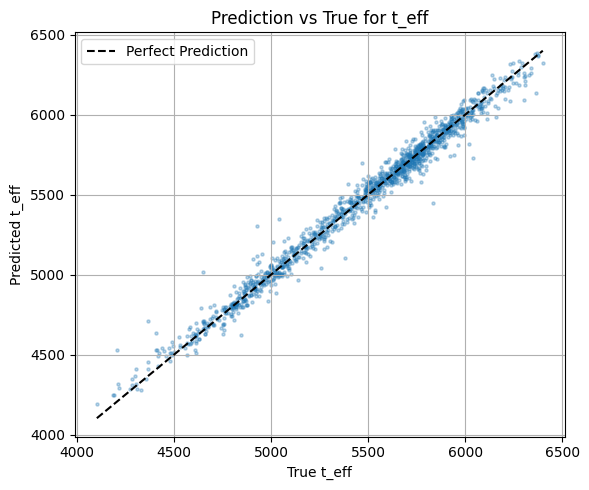

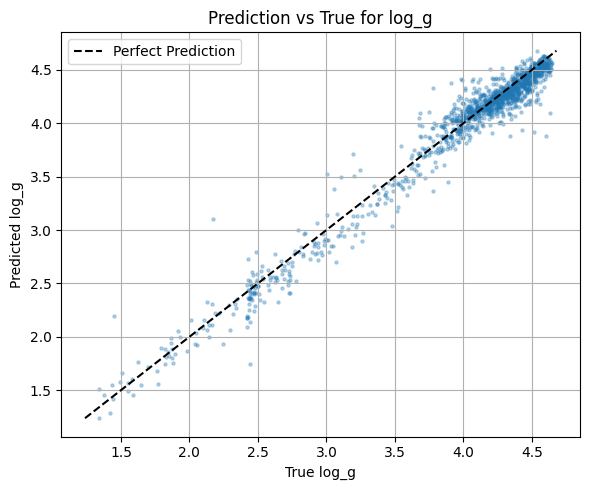

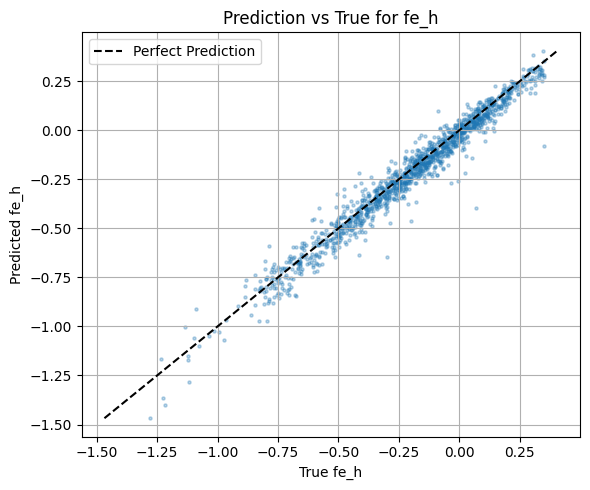

In [25]:
import matplotlib.pyplot as plt

mu_denorm = denormalize(mu, ranges)
labels_denorm = denormalize(labels, ranges)

for j in range(3):
    plt.figure(figsize=(6, 5))
    plt.scatter(labels_denorm[:, j], mu_denorm[:, j], alpha=0.3, s=5)
    min_val = min(labels_denorm[:, j].min(), mu_denorm[:, j].min())
    max_val = max(labels_denorm[:, j].max(), mu_denorm[:, j].max())
    plt.plot([min_val, max_val], [min_val, max_val], 'k--', label="Perfect Prediction")
    plt.xlabel(f"True {labelNames[j]}")
    plt.ylabel(f"Predicted {labelNames[j]}")
    plt.title(f"Prediction vs True for {labelNames[j]}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()




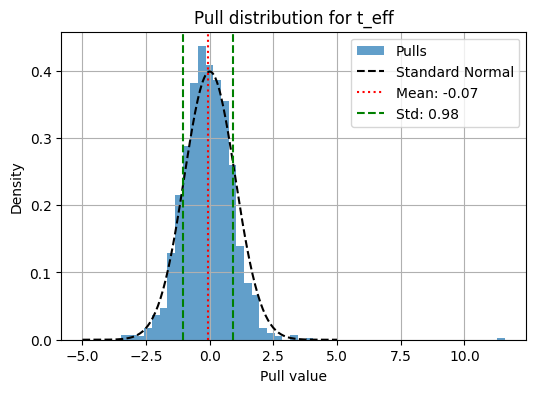

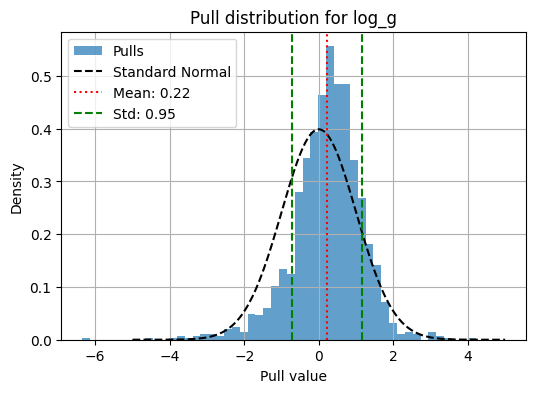

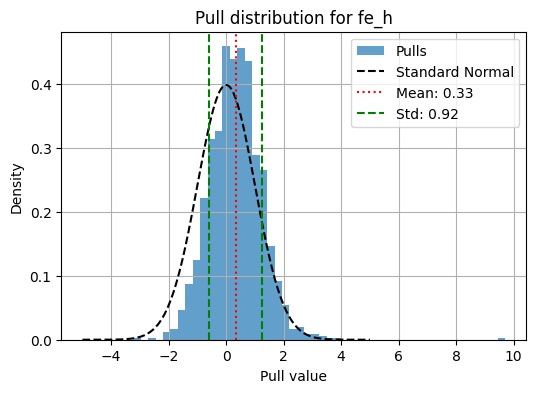

In [26]:
import scipy.stats as stats

for j in range(3):
    plt.figure(figsize=(6, 4))
    plt.hist(pulls[:, j], bins=50, density=True, alpha=0.7, label='Pulls')
    x = np.linspace(-5, 5, 200)
    plt.plot(x, stats.norm.pdf(x), 'k--', label='Standard Normal')
    plt.axvline(pulls[:, j].mean(), color='r', linestyle=':', label=f'Mean: {pulls[:, j].mean():.2f}')
    plt.axvline(pulls[:, j].mean() + pulls[:, j].std(), color='g', linestyle='--', label=f'Std: {pulls[:, j].std():.2f}')
    plt.axvline(pulls[:, j].mean() - pulls[:, j].std(), color='g', linestyle='--')
    plt.title(f"Pull distribution for {labelNames[j]}")
    plt.xlabel("Pull value")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True)
    plt.show()


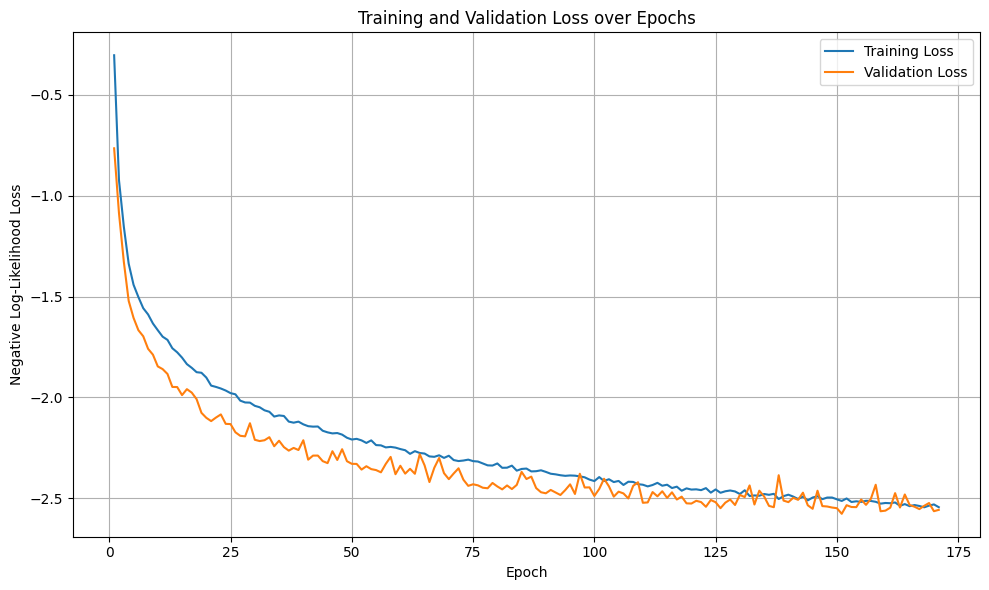

In [27]:



plt.figure(figsize=(10, 6))
plt.plot(range(1, len(train_losses) + 1), train_losses, label='Training Loss')
plt.plot(range(1, len(val_losses) + 1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Negative Log-Likelihood Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
